# 1. Carga de bibliotecas

Seccion para instalar e importar bibliotecas necesarias

In [ ]:
# Acá instalamos la biblioteca fitter para el ajuste de funciones
!pip install fitter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv

In [ ]:
# Acá importarmos todas las bibliotecas necesarias: Pandas, Numpy, Scipy y Fitter
from fitter import Fitter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
# Esto se hace para montar el gogle drive y poder acceder datos alojados allí.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. Carga de datos

Utilizaremos los datos de recorrido de bicicletas públicas de la ciudad de Buenos Aires
https://data.buenosaires.gob.ar/dataset/bicicletas-publicas

Bajaremos el archivo "Recorridos Realizados 2023 (ZIP)", descomprimiremos el archivo csv presente ("trips_2023.csv")y lo alojamos dentro de la carpeta "Colab Notebooks" de nuestro Google Drive




In [ ]:
# En esta parte del código se debe modificar la ubicación correcta del google drive
tickets = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/EPIO/Datos/tickets_soporte.csv')

# 3. Análisis Exploratorio de Datos

In [ ]:
type(tickets)

pandas.core.frame.DataFrame

In [ ]:
# Primeras lineas de nuestro dataframe
tickets.head()

,idTicket,Área,fecha_hora_apertura,fecha_hora_asignación,fecha_hora_cierre,id_soporte
0,1,Alumnos,2025-09-01 09:00:00,2025-09-01 09:00:00.000000,2025-09-01 09:23:04.700528,S1
1,2,Alumnos,2025-09-01 09:42:07,2025-09-01 09:42:07.000000,2025-09-01 10:05:56.125112,S2
2,3,Alumnos,2025-09-01 09:52:09,2025-09-01 09:52:09.000000,2025-09-01 10:22:34.000000,S3
3,4,Alumnos,2025-09-01 10:00:51,2025-09-01 10:00:51.000000,2025-09-01 10:20:29.402926,S1
4,5,Alumnos,2025-09-01 10:09:20,2025-09-01 10:09:20.000000,2025-09-01 10:37:30.404115,S2


In [ ]:
# Dimensionalidad del dataframe
tickets.shape

(4000, 6)

# 4. Preparación de Datos

Si debo modificar una columna, es conveniente crear una nueva y no pisar la original. Lo mismo para los dataframes

In [ ]:
# Creo dos nuevas columnas con las fechas con el tipo de dato correcto.
tickets['fecha_hora_cierre_dt'] = pd.to_datetime(tickets['fecha_hora_cierre'])
tickets['fecha_hora_apertura_dt'] = pd.to_datetime(tickets['fecha_hora_apertura'])
tickets['fecha_hora_asignación_dt'] = pd.to_datetime(tickets['fecha_hora_asignación'])

In [ ]:
tickets.head(50)

,idTicket,Área,nombre_persona_soporte,fecha_hora_apertura,fecha_hora_asignación,fecha_hora_cierre,fecha_hora_cierre_dt,fecha_hora_apertura_dt,fecha_hora_asignación_dt,duracion_atencion_dt,tiempo_espera_dt
0,1,Gestión Académica,Ana López,2025-09-01 09:00:00,2025-09-01 09:00:00,2025-09-01 09:16:00,2025-09-01 09:16:00,2025-09-01 09:00:00,2025-09-01 09:00:00,16.0,0.0
1,2,Gestión Académica,Carlos Méndez,2025-09-01 09:13:00,2025-09-01 09:13:00,2025-09-01 09:36:00,2025-09-01 09:36:00,2025-09-01 09:13:00,2025-09-01 09:13:00,23.0,0.0
2,3,Alumnos,María García,2025-09-01 10:04:00,2025-09-01 10:04:00,2025-09-01 10:32:00,2025-09-01 10:32:00,2025-09-01 10:04:00,2025-09-01 10:04:00,28.0,0.0
3,4,Otros,Diego Pérez,2025-09-01 10:09:00,2025-09-01 10:09:00,2025-09-01 10:12:00,2025-09-01 10:12:00,2025-09-01 10:09:00,2025-09-01 10:09:00,3.0,0.0
4,5,Otros,Valentina Torres,2025-09-01 10:26:00,2025-09-01 10:26:00,2025-09-01 10:36:00,2025-09-01 10:36:00,2025-09-01 10:26:00,2025-09-01 10:26:00,10.0,0.0
5,6,Gestión Académica,Lucía Fernández,2025-09-01 10:27:00,2025-09-01 10:27:00,2025-09-01 10:50:00,2025-09-01 10:50:00,2025-09-01 10:27:00,2025-09-01 10:27:00,23.0,0.0
6,7,Gestión Académica,Ana López,2025-09-01 10:55:00,2025-09-01 10:55:00,2025-09-01 11:21:00,2025-09-01 11:21:00,2025-09-01 10:55:00,2025-09-01 10:55:00,26.0,0.0
7,8,Alumnos,Javier Díaz,2025-09-01 10:56:00,2025-09-01 10:56:00,2025-09-01 11:11:00,2025-09-01 11:11:00,2025-09-01 10:56:00,2025-09-01 10:56:00,15.0,0.0
8,9,Alumnos,Sofía Romero,2025-09-01 11:07:00,2025-09-01 11:07:00,2025-09-01 11:18:00,2025-09-01 11:18:00,2025-09-01 11:07:00,2025-09-01 11:07:00,11.0,0.0
9,10,Otros,Nicolás Herrera,2025-09-01 11:12:00,2025-09-01 11:12:00,2025-09-01 11:16:00,2025-09-01 11:16:00,2025-09-01 11:12:00,2025-09-01 11:12:00,4.0,0.0


In [ ]:
tickets.dtypes

,0
idTicket,int64
Área,object
nombre_persona_soporte,object
fecha_hora_apertura,object
fecha_hora_asignación,object
fecha_hora_cierre,object
fecha_hora_cierre_dt,datetime64[ns]
fecha_hora_apertura_dt,datetime64[ns]
fecha_hora_asignación_dt,datetime64[ns]


In [ ]:
# Calculo la diferencia de tiempo y los llamo duracion_recorrido_dt
tickets['duracion_atencion_dt'] = tickets['fecha_hora_cierre_dt'] - tickets['fecha_hora_asignación_dt']
tickets['tiempo_espera_dt'] = tickets['fecha_hora_asignación_dt'] - tickets['fecha_hora_apertura_dt']

In [ ]:
tickets.head(50)

,idTicket,Área,nombre_persona_soporte,fecha_hora_apertura,fecha_hora_asignación,fecha_hora_cierre,fecha_hora_cierre_dt,fecha_hora_apertura_dt,fecha_hora_asignación_dt,duracion_atencion_dt,tiempo_espera_dt
0,1,Alumnos,María García,2025-09-01 09:00:00,2025-09-01 09:00:00.000000,2025-09-01 09:23:04.700528,2025-09-01 09:23:04.700528,2025-09-01 09:00:00,2025-09-01 09:00:00.000000,23.078342,0.000000
1,2,Alumnos,Javier Díaz,2025-09-01 09:42:07,2025-09-01 09:42:07.000000,2025-09-01 10:05:56.125112,2025-09-01 10:05:56.125112,2025-09-01 09:42:07,2025-09-01 09:42:07.000000,23.818752,0.000000
2,3,Alumnos,Sofía Romero,2025-09-01 09:52:09,2025-09-01 09:52:09.000000,2025-09-01 10:22:34.000000,2025-09-01 10:22:34.000000,2025-09-01 09:52:09,2025-09-01 09:52:09.000000,30.416667,0.000000
3,4,Alumnos,María García,2025-09-01 10:00:51,2025-09-01 10:00:51.000000,2025-09-01 10:20:29.402926,2025-09-01 10:20:29.402926,2025-09-01 10:00:51,2025-09-01 10:00:51.000000,19.640049,0.000000
4,5,Alumnos,Javier Díaz,2025-09-01 10:09:20,2025-09-01 10:09:20.000000,2025-09-01 10:37:30.404115,2025-09-01 10:37:30.404115,2025-09-01 10:09:20,2025-09-01 10:09:20.000000,28.173402,0.000000
5,6,Alumnos,María García,2025-09-01 10:57:47,2025-09-01 10:57:47.000000,2025-09-01 11:28:05.317074,2025-09-01 11:28:05.317074,2025-09-01 10:57:47,2025-09-01 10:57:47.000000,30.305285,0.000000
6,7,Alumnos,Sofía Romero,2025-09-01 11:07:57,2025-09-01 11:07:57.000000,2025-09-01 11:36:32.559469,2025-09-01 11:36:32.559469,2025-09-01 11:07:57,2025-09-01 11:07:57.000000,28.592658,0.000000
7,8,Alumnos,Javier Díaz,2025-09-01 11:12:03,2025-09-01 11:12:03.000000,2025-09-01 11:35:25.066842,2025-09-01 11:35:25.066842,2025-09-01 11:12:03,2025-09-01 11:12:03.000000,23.367781,0.000000
8,9,Alumnos,María García,2025-09-01 11:29:36,2025-09-01 11:29:36.000000,2025-09-01 11:50:26.067528,2025-09-01 11:50:26.067528,2025-09-01 11:29:36,2025-09-01 11:29:36.000000,20.834459,0.000000
9,10,Gestión Académica,Ana López,2025-09-01 11:44:29,2025-09-01 11:44:29.000000,2025-09-01 11:55:53.474807,2025-09-01 11:55:53.474807,2025-09-01 11:44:29,2025-09-01 11:44:29.000000,11.407913,0.000000


In [ ]:
# El tipo de dato de la nueva columna no resulta conveniente:
tickets.dtypes

,0
idTicket,int64
Área,object
nombre_persona_soporte,object
fecha_hora_apertura,object
fecha_hora_asignación,object
fecha_hora_cierre,object
fecha_hora_cierre_dt,datetime64[ns]
fecha_hora_apertura_dt,datetime64[ns]
fecha_hora_asignación_dt,datetime64[ns]
duracion_atencion_dt,timedelta64[ns]


In [ ]:
# Por ende creo una nueva columna con los valores de minutos totales con formato float
tickets['duracion_atencion_dt'] = tickets['duracion_atencion_dt'].dt.total_seconds() / 60
tickets['tiempo_espera_dt'] = tickets['tiempo_espera_dt'].dt.total_seconds() / 60

In [ ]:
tickets_gestion_academica = tickets[tickets['Área'] == 'Gestión Académica']
tickets_alumnos = tickets[tickets['Área'] == 'Alumnos']
#tickets_otros = tickets[tickets['Área'] == 'Otros']

In [ ]:
tickets_gestion_academica.head(50)


,idTicket,Área,nombre_persona_soporte,fecha_hora_apertura,fecha_hora_asignación,fecha_hora_cierre,fecha_hora_cierre_dt,fecha_hora_apertura_dt,fecha_hora_asignación_dt,duracion_atencion_dt,tiempo_espera_dt,intervalo_entre_arribos,intervalo_entre_arribos_min
9,10,Gestión Académica,Ana López,2025-09-01 11:44:29,2025-09-01 11:44:29.000000,2025-09-01 11:55:53.474807,2025-09-01 11:55:53.474807,2025-09-01 11:44:29,2025-09-01 11:44:29.000000,11.407913,0.000000,NaN,NaN
10,11,Gestión Académica,Carlos Méndez,2025-09-01 11:51:10,2025-09-01 11:51:10.000000,2025-09-01 12:01:50.255191,2025-09-01 12:01:50.255191,2025-09-01 11:51:10,2025-09-01 11:51:10.000000,10.670920,0.000000,6.683333,6.683333
11,12,Gestión Académica,Lucía Fernández,2025-09-01 11:53:40,2025-09-01 11:53:40.000000,2025-09-01 12:04:41.375389,2025-09-01 12:04:41.375389,2025-09-01 11:53:40,2025-09-01 11:53:40.000000,11.022923,0.000000,2.500000,2.500000
12,13,Gestión Académica,Ana López,2025-09-01 12:13:36,2025-09-01 12:13:36.000000,2025-09-01 12:23:33.036471,2025-09-01 12:23:33.036471,2025-09-01 12:13:36,2025-09-01 12:13:36.000000,9.950608,0.000000,19.933333,19.933333
13,14,Gestión Académica,Carlos Méndez,2025-09-01 12:15:01,2025-09-01 12:15:01.000000,2025-09-01 12:19:23.374605,2025-09-01 12:19:23.374605,2025-09-01 12:15:01,2025-09-01 12:15:01.000000,4.372910,0.000000,1.416667,1.416667
14,15,Gestión Académica,Lucía Fernández,2025-09-01 12:18:04,2025-09-01 12:18:04.000000,2025-09-01 12:30:36.052533,2025-09-01 12:30:36.052533,2025-09-01 12:18:04,2025-09-01 12:18:04.000000,12.534209,0.000000,3.050000,3.050000
15,16,Gestión Académica,Carlos Méndez,2025-09-01 12:28:35,2025-09-01 12:28:35.000000,2025-09-01 12:36:08.713465,2025-09-01 12:36:08.713465,2025-09-01 12:28:35,2025-09-01 12:28:35.000000,7.561891,0.000000,10.516667,10.516667
16,17,Gestión Académica,Ana López,2025-09-01 12:31:11,2025-09-01 12:31:11.000000,2025-09-01 12:51:57.000730,2025-09-01 12:51:57.000730,2025-09-01 12:31:11,2025-09-01 12:31:11.000000,20.766679,0.000000,2.600000,2.600000
17,18,Gestión Académica,Lucía Fernández,2025-09-01 12:41:51,2025-09-01 12:41:51.000000,2025-09-01 12:50:52.158905,2025-09-01 12:50:52.158905,2025-09-01 12:41:51,2025-09-01 12:41:51.000000,9.019315,0.000000,10.666667,10.666667
26,27,Gestión Académica,Carlos Méndez,2025-09-01 13:51:14,2025-09-01 13:51:14.000000,2025-09-01 14:03:24.570545,2025-09-01 14:03:24.570545,2025-09-01 13:51:14,2025-09-01 13:51:14.000000,12.176176,0.000000,69.383333,69.383333


In [ ]:
tickets_alumnos.shape

(1924, 11)

In [ ]:
tickets_gestion_academica.shape

(2076, 11)

Text(0.5, 1.0, 'Distribución de duración de atención en Alumnos')

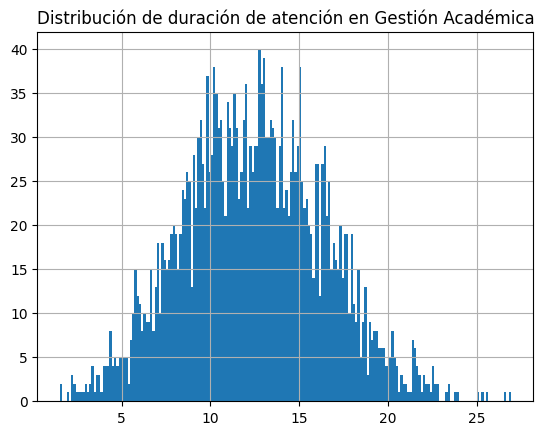

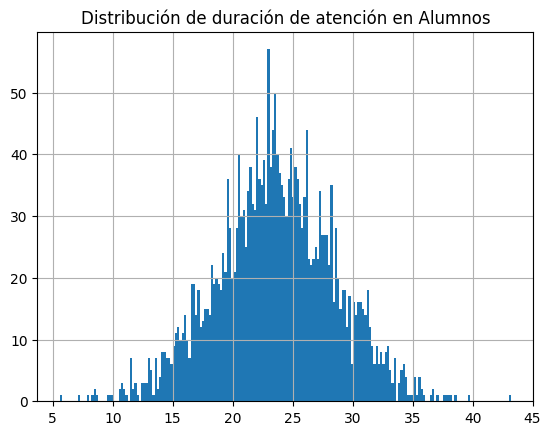

In [ ]:
# Con el histograma veo que tengo datos anómalos, mas alla de los 60 minutos.
tickets_gestion_academica.hist('duracion_atencion_dt', bins=200)
plt.title('Distribución de duración de atención en Gestión Académica')
tickets_alumnos.hist('duracion_atencion_dt', bins=200)
plt.title('Distribución de duración de atención en Alumnos')
#tickets_otros.hist('duracion_atencion_dt', bins=200)
#plt.title('Distribución de duración de atención en Otros')

In [ ]:
import pandas as pd

def calcular_intervalo_sin_orden(df):
    df = df.copy()

    # Asegurar tipo datetime (YYYY-MM-DD HH:MM:SS es formato estándar)
    df["fecha_hora_apertura"] = pd.to_datetime(df["fecha_hora_apertura"], errors="coerce")

    # Ordenar por fecha de apertura
    df = df.sort_values(by='fecha_hora_apertura')

    # Diferencia con la fila anterior (respeta el orden actual del DF)
    df["intervalo_entre_arribos"] = df["fecha_hora_apertura"].diff()

    # Detectar cambio de día
    cambio_de_dia = (
        df["fecha_hora_apertura"].dt.normalize()
        != df["fecha_hora_apertura"].shift().dt.normalize()
    )

    # Para el primer ticket de cada día: no calcular (NaT)
    df.loc[cambio_de_dia, "intervalo_entre_arribos"] = pd.NaT

    return df

tickets_gestion_academica = calcular_intervalo_sin_orden(tickets_gestion_academica)
tickets_alumnos = calcular_intervalo_sin_orden(tickets_alumnos)
#tickets_otros = calcular_intervalo_sin_orden(tickets_otros)

# (Opcional) en minutos, NaN donde no corresponde
for subdf in (tickets_gestion_academica, tickets_alumnos): #Aca saqué el de otros
    subdf["intervalo_entre_arribos_min"] = (
        subdf["intervalo_entre_arribos"].dt.total_seconds().div(60)
    )

In [ ]:
# Convertir el intervalo a minutos (ya no es necesario dividir por 60 después de ordenar)
tickets_alumnos['intervalo_entre_arribos'] = tickets_alumnos['intervalo_entre_arribos'].dt.total_seconds() / 60
tickets_gestion_academica['intervalo_entre_arribos'] = tickets_gestion_academica['intervalo_entre_arribos'].dt.total_seconds() / 60
##tickets_otros['intervalo_entre_arribos'] = tickets_otros['intervalo_entre_arribos'].dt.total_seconds() / 60

In [ ]:
tickets_gestion_academica.head(50)

NameError: name 'tickets_gestion_academica' is not defined

In [ ]:
tickets_gestion_academica_cleaned = tickets_gestion_academica.dropna(subset=['intervalo_entre_arribos'])
tickets_alumnos_cleaned = tickets_alumnos.dropna(subset=['intervalo_entre_arribos'])
#tickets_otros_cleaned = tickets_otros.dropna(subset=['intervalo_entre_arribos'])

Text(0.5, 1.0, 'Distribución de intervalo entre arribos en Alumnos')

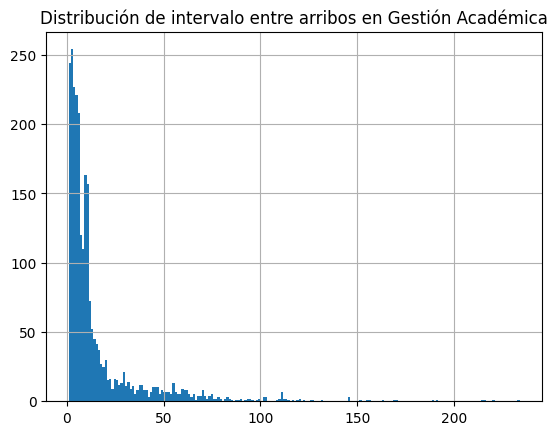

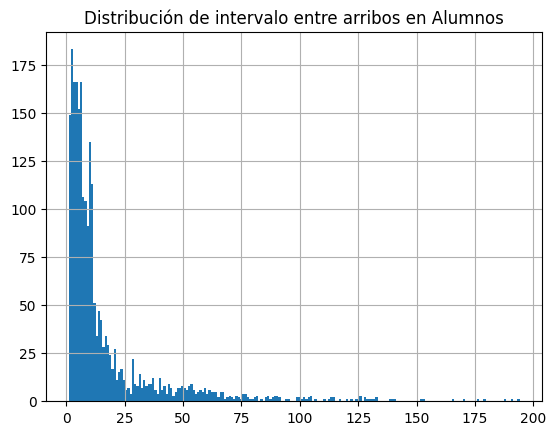

In [ ]:
# Con el histograma veo que tengo datos anómalos, mas alla de los 60 minutos.
tickets_gestion_academica_cleaned.hist('intervalo_entre_arribos', bins=200)
plt.title('Distribución de intervalo entre arribos en Gestión Académica')
tickets_alumnos_cleaned.hist('intervalo_entre_arribos', bins=200)
plt.title('Distribución de intervalo entre arribos en Alumnos')
#tickets_otros_cleaned.hist('intervalo_entre_arribos', bins=200)
#plt.title('Distribución de intervalo entre arribos en Otros')

# 5. Cálculo de FDPS

In [ ]:
# En una variable preparar la columna del df que quiero ajustar
fdp_TA_Gestion_Academica = Fitter(tickets_gestion_academica.duracion_atencion_dt)
fdp_TA_Alumnos = Fitter(tickets_alumnos.duracion_atencion_dt)
#fdp_TA_Otros = Fitter(tickets_otros.duracion_atencion_dt)
fdp_IA_Gestion_Academica = Fitter(tickets_gestion_academica_cleaned.intervalo_entre_arribos)
fdp_IA_Alumnos = Fitter(tickets_alumnos_cleaned.intervalo_entre_arribos)
#fdp_IA_Otros = Fitter(tickets_otros_cleaned.intervalo_entre_arribos)


In [ ]:
# Con el método fit() ajusta mis datos a las 80 distribuciones de SciPy
fdp_TA_Gestion_Academica.fit()
fdp_TA_Alumnos.fit()
#fdp_TA_Otros.fit()
fdp_IA_Gestion_Academica.fit()
fdp_IA_Alumnos.fit()
#fdp_IA_Otros.fit()

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
gennorm,0.005845,837.128048,854.701651,inf,0.017357,0.412495
gengamma,0.005861,825.384170,848.815641,inf,0.011114,0.903163
gausshyper,0.005867,829.904052,865.051257,inf,0.010287,0.944544
beta,0.005871,825.619530,849.051000,inf,0.010386,0.940272
johnsonsb,0.005874,825.721607,849.153078,inf,0.010461,0.936882
weibull_min,0.005932,831.045614,848.619216,inf,0.011959,0.848865
burr12,0.005954,821.995984,845.427455,inf,0.013062,0.764477
powerlognorm,0.005965,817.542088,840.973559,inf,0.012224,0.829754
rice,0.006018,817.988007,835.561610,inf,0.014290,0.661024
powernorm,0.006091,815.122477,832.696080,inf,0.014183,0.670165


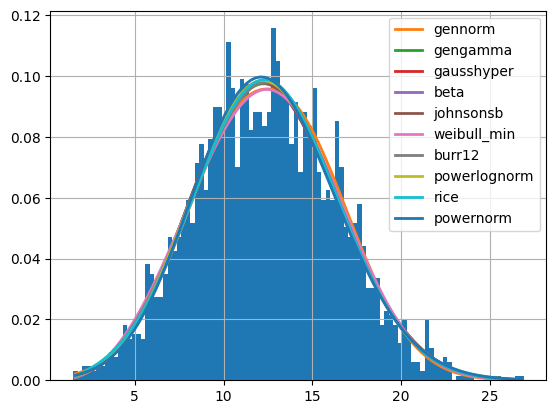

In [ ]:
# Summary me muestra el resumen de los mejores ajustes
fdp_TA_Gestion_Academica.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
gennorm,0.003532,978.018244,995.385365,inf,0.011224,0.917884
dpareto_lognorm,0.003600,976.085566,1010.819808,inf,0.013942,0.730496
genhyperbolic,0.003632,958.887095,987.832297,inf,0.492543,0.000000
t,0.003729,981.148396,998.515517,inf,0.014041,0.722445
norminvgauss,0.003731,985.706017,1008.862179,inf,0.013522,0.764045
vonmises_line,0.003741,982.002261,999.369382,inf,0.014354,0.696893
burr12,0.003801,978.698529,1001.854691,inf,0.016912,0.489482
genlogistic,0.003833,933.619186,950.986307,inf,0.019313,0.324703
powernorm,0.003837,998.947567,1016.314688,inf,0.015397,0.610625
johnsonsu,0.003839,1000.256216,1023.412377,inf,0.017004,0.482447


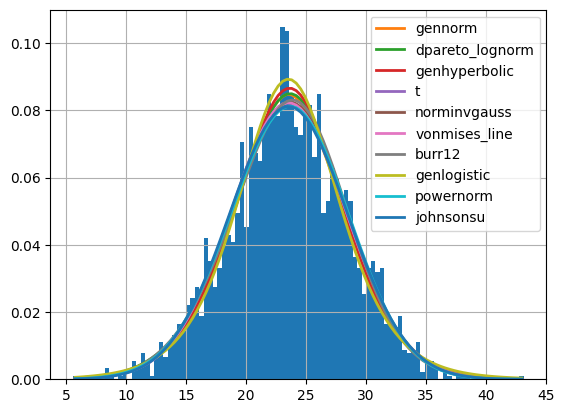

In [ ]:
fdp_TA_Alumnos.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
foldcauchy,0.000211,1538.641969,1556.115307,inf,0.025372,7.856184e-02
kappa3,0.000261,1704.049682,1721.523020,inf,0.067208,2.885314e-10
burr,0.000322,1581.938080,1605.235864,inf,0.041040,4.258093e-04
mielke,0.000322,1581.798391,1605.096175,inf,0.041032,4.272750e-04
invgamma,0.000324,1561.613271,1579.086609,inf,0.031973,1.176842e-02
genextreme,0.000334,1554.136124,1571.609462,inf,0.033645,6.789307e-03
invweibull,0.000334,1554.133114,1571.606452,inf,0.033645,6.788835e-03
jf_skew_t,0.000347,1561.920962,1585.218746,inf,0.038565,1.143417e-03
nct,0.000348,1560.955502,1584.253285,inf,0.037212,1.911895e-03
halfcauchy,0.000354,1514.517401,1526.166293,inf,0.041956,2.909103e-04


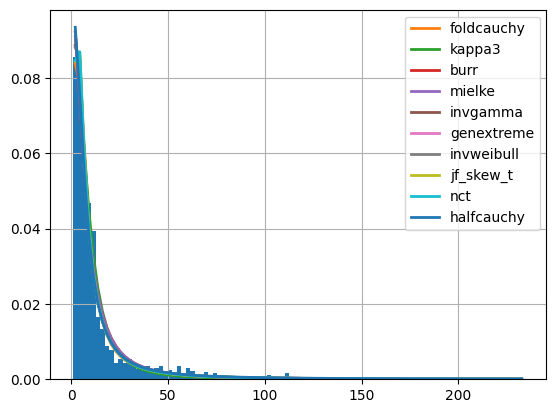

In [ ]:
fdp_IA_Gestion_Academica.summary(10)

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
foldcauchy,0.000280,1454.029061,1471.288644,inf,0.024571,0.118162
dpareto_lognorm,0.000404,1486.669888,1521.189054,inf,0.032036,0.016418
fisk,0.000432,1464.706570,1481.966153,inf,0.034749,0.007046
burr,0.000444,1479.482250,1502.495027,inf,0.038566,0.001907
mielke,0.000444,1479.482005,1502.494782,inf,0.038566,0.001907
ncf,0.000447,1475.226253,1503.992224,inf,0.028294,0.047126
invgamma,0.000486,1468.382034,1485.641617,inf,0.027866,0.052727
invweibull,0.000510,1463.533307,1480.792890,inf,0.026303,0.078294
genextreme,0.000510,1463.533315,1480.792898,inf,0.026303,0.078292
burr12,0.000518,1481.369348,1504.382125,inf,0.042690,0.000399


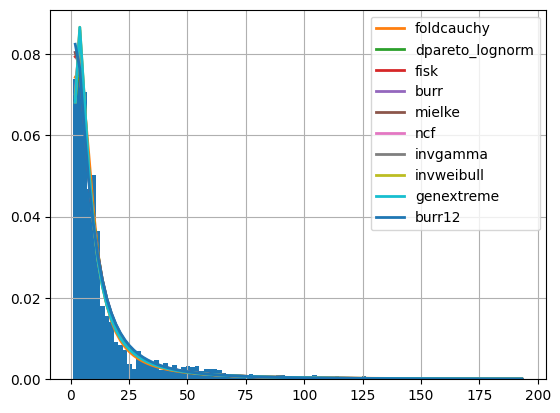

In [ ]:
fdp_IA_Alumnos.summary(10)

# 6. Simulacion

In [ ]:
# get_best me devuelve la mejor distribución de acuerdo al criterio que le indico y sus parámetros
fdp_TA_Gestion_Academica.get_best(method='sumsquare_error')

{'gennorm': {'beta': 2.207237162715657,
  'loc': 12.476341431070377,
  'scale': 5.895534092625402}}

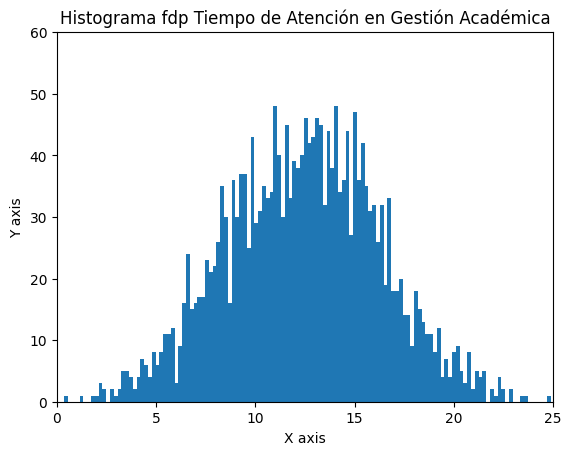

In [ ]:
beta_TA_GA = 2.207237162715657
loc_TA_GA = 12.476341431070377
scale_TA_GA = 5.895534092625402

fdp_f_TA_GA = stats.gennorm.rvs(beta = beta_TA_GA , loc= loc_TA_GA, scale=scale_TA_GA, size = 2200)

# Histograma de datos de verificación
plt.title("Histograma fdp Tiempo de Atención en Gestión Académica")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0, 25)
plt.ylim(0, 60)
plt.hist(fdp_f_TA_GA, bins=150)
plt.show()


In [ ]:
fdp_TA_Alumnos.get_best(method='sumsquare_error')

{'gennorm': {'beta': 1.8331068455079633,
  'loc': 23.56547209570904,
  'scale': 6.634904447389176}}

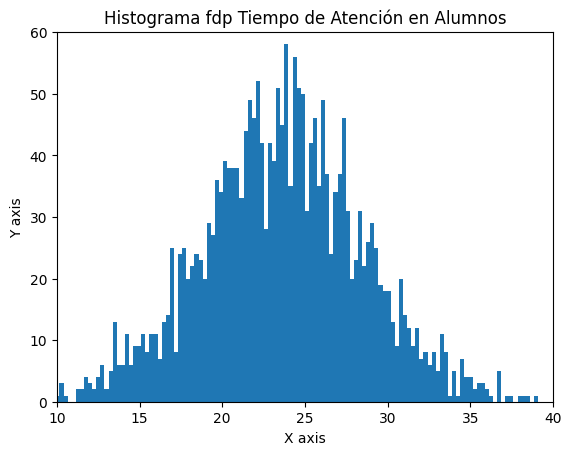

In [ ]:
beta_TA_Alumnos = 1.8331068455079633
loc_TA_Alumnos = 23.56547209570904
scale_TA_Alumnos = 6.634904447389176

fdp_f_TA_Alumnos = stats.gennorm.rvs(beta = beta_TA_Alumnos, loc= loc_TA_Alumnos, scale=scale_TA_Alumnos, size = 2200)

# Histograma de datos de verificación
plt.title("Histograma fdp Tiempo de Atención en Alumnos")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(10, 40)
plt.ylim(0, 60)
plt.hist(fdp_f_TA_Alumnos, bins=150)
plt.show()


In [ ]:
fdp_IA_Gestion_Academica.get_best(method='sumsquare_error')

{'foldcauchy': {'c': 0.5561228593754299,
  'loc': 1.016666665640046,
  'scale': 5.788069654548192}}

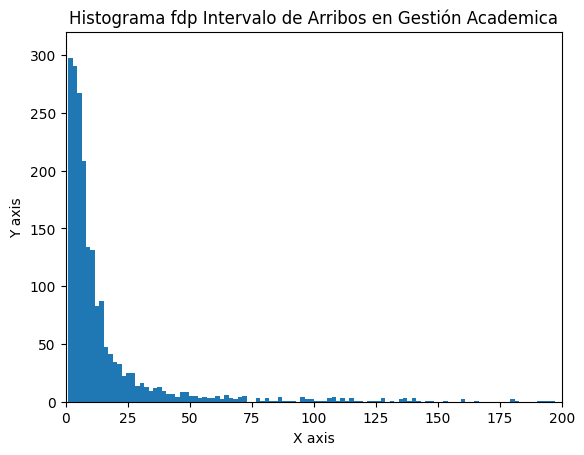

In [ ]:
c_IA_GA = 0.5561228593754299
loc_IA_GA = 1.016666665640046
scale_IA_GA = 5.788069654548192

fdp_f_IA_GA = stats.foldcauchy.rvs( c  = c_IA_GA ,loc= loc_IA_GA, scale=scale_IA_GA, size = 2000)

# Histograma de datos de verificación
plt.title("Histograma fdp Intervalo de Arribos en Gestión Academica")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0, 200)
plt.ylim(0, 320)
plt.hist(fdp_f_IA_GA, bins='auto')
plt.show()

In [ ]:
fdp_IA_Alumnos.get_best(method='sumsquare_error')

{'foldcauchy': {'c': 0.6257022419470324,
  'loc': 0.9999999933988453,
  'scale': 6.172313207823716}}

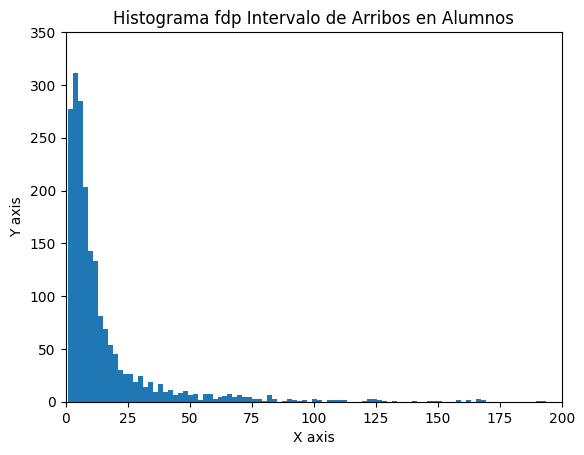

In [ ]:
c_IA_Alumnos = 0.6257022419470324
loc_IA_Alumnos = 0.9999999933988453
scale_IA_Alumnos = 6.172313207823716

fdp_f_IA_Alumnos = stats.foldcauchy.rvs(c = c_IA_Alumnos ,loc= loc_IA_Alumnos, scale=scale_IA_Alumnos, size = 2000)

# Histograma de datos de verificación
plt.title("Histograma fdp Intervalo de Arribos en Alumnos")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.xlim(0, 200)
plt.ylim(0, 350)
plt.hist(fdp_f_IA_Alumnos, bins='auto')
plt.show()